---
title: xarray EOPF backend: Sentinel-1
Subtitle: Access Sentinel-1 in Native Mode
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-1", "xarray-eopf", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

## Table of Contents
1. [Introduction](#Introduction_XEOPF_SEN1_NATIVE)
2. [Import modules](#Import_XEOPF_SEN1_NATIVE)
3. [Open a Sentinel-1 GRD](#Open_GRD_XEOPF_SEN1_NATIVE)
4. [Open a Sentinel-1 Level-2 OCN](#Open_OCN_XEOPF_SEN1_NATIVE)
5. [Conclusion](#Conclusion_XEOPF_SEN1_NATIVE)

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

(Introduction_XEOPF_SEN1_NATIVE)=
## Introduction

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-1** EOPF Zarr products in **native mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. 

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).

- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

:::{hint} Overview
**Questions**
- How can I use the xarray-eopf backend for Sentinel-1 in native mode?
- What main features does the xarray-eopf backend provide for Sentinel-1 in native mode?

**Objectives**
- Learn how to open Sentinel-1 EOPF Zarr products using `xarray-eopf`.
- Understand the key features and capabilities of the `xarray-eopf` backend in native mode for Sentinel-1.
:::

---

(Import_XEOPF_SEN1_NATIVE)=
## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import datetime

import matplotlib.pyplot as plt
import pystac_client
import xarray as xr

---

(Open_GRD_XEOPF_SEN1_NATIVE)=
## Open a Sentinel-1 GRD 

We begin with an example that accesses a Sentinel-1 GRD product in **native mode**. 

---

### Find a Sentinel-1 GRD Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd) to search for a Sentinel-1 GRD tile.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=30)), None],
    ).items()
)
items

[<Item id=S1C_IW_GRDH_1SDV_20260329T173003_20260329T173028_006982_00E226_9BA1>,
 <Item id=S1A_IW_GRDH_1SDV_20260329T053552_20260329T053617_063838_080734_1F29>,
 <Item id=S1C_IW_GRDH_1SDV_20260328T054254_20260328T054319_006960_00E156_9271>,
 <Item id=S1C_IW_GRDH_1SDV_20260324T172158_20260324T172223_006909_00DF9C_BC61>,
 <Item id=S1A_IW_GRDH_1SDV_20260323T173113_20260323T173138_063758_080437_1B1F>,
 <Item id=S1C_IW_GRDH_1SDV_20260323T053505_20260323T053530_006887_00DED8_A071>,
 <Item id=S1C_IW_GRDH_1SDV_20260323T053440_20260323T053505_006887_00DED8_C5E4>,
 <Item id=S1A_IW_GRDH_1SDV_20260322T054415_20260322T054440_063736_080362_7F26>,
 <Item id=S1A_IW_GRDH_1SDV_20260322T054350_20260322T054415_063736_080362_32F4>,
 <Item id=S1A_IW_GRDH_1SDV_20260318T172306_20260318T172331_063685_080176_BEF4>,
 <Item id=S1C_IW_GRDH_1SDV_20260317T173003_20260317T173028_006807_00DC26_BF98>,
 <Item id=S1A_IW_GRDH_1SDV_20260317T053552_20260317T053617_063663_0800AA_468A>,
 <Item id=S1C_IW_GRDH_1SDV_20260316T0542

Next, we can inspect the item’s contents, including the additional field `xarray:open_datatree_kwargs`, which provides the arguments needed to open the product using Xarray’s `eopf-zarr` engine.

In [3]:
item = items[1]
item

<Item id=S1A_IW_GRDH_1SDV_20260329T053552_20260329T053617_063838_080734_1F29>

### Open Sentinel-1 GRD in native mode as DataTree

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [4]:
%%time
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)
dt

CPU times: user 1.96 s, sys: 332 ms, total: 2.29 s
Wall time: 7.32 s


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /S01SIWGRD_20260329T053552_0025_A365_1F29_080734_VH
│   │   Attributes: (3)
│   ├── Group: /S01SIWGRD_20260329T053552_0025_A365_1F29_080734_VH/conditions
│   │   ├── Group: /S01SIWGRD_20260329T053552_0025_A365_1F29_080734_VH/conditions/antenna_pattern
│   │   │       Dimensions:              (azimuth_time: 27, count: 721)
│   │   │       Coordinates:
│   │   │         * azimuth_time         (azimuth_time) datetime64[ns] 216B 2026-03-29T05:35:...
│   │   │         * count                (count) int64 6kB 0 1 2 3 4 5 ... 716 717 718 719 720
│   │   │       Data variables:
│   │   │           elevation_angle      (azimuth_time, count) float32 78kB dask.array<chunksize=(27, 721), meta=np.ndarray>
│   │   │           incidence_angle      (azimuth_time, count) float32 78kB dask.array<chunksize=(27, 721), meta=np.ndarray>
│   │   │           roll                 (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           slant_range_time_ap  (azimuth_time, count) float64 156kB dask.array<chunksize=(27, 721), meta=np.ndarray>
│   │   │           swath                (azimuth_time) <U3 324B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           terrain_height       (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260329T053552_0025_A365_1F29_080734_VH/conditions/attitude
│   │   │       Dimensions:       (azimuth_time: 25)
│   │   │       Coordinates:
│   │   │         * azimuth_time  (azimuth_time) datetime64[ns] 200B 2026-03-29T05:35:52.8749...
│   │   │       Data variables:
│   │   │           pitch         (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q0            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q1            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q2            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q3            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           roll          (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wx            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wy            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wz            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           yaw           (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260329T053552_0025_A365_1F29_080734_VH/conditions/doppler_centroid
│   │   │       Dimensions:                            (azimuth_time: 27, degree: 3)
│   │   │       Coordinates:
│   │   │         * azimuth_time                       (azimuth_time) datetime64[ns] 216B 202...
│   │   │         * degree                             (degree) int64 24B 2 1 0
│   │   │       Data variables:
│   │   │           data_dc_polynomial                 (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           data_dc_rms_error                  (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           data_dc_rms_error_above_threshold  (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_start_time        (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_stop_time         (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           geometry_dc_polynomial             (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           t0                                 (azimuth_time) float64 216

We can extract the `first band as shown below: 

In [5]:
ds = dt[dt.groups[1]].measurements.to_dataset()
ds

<xarray.Dataset> Size: 884MB
Dimensions:       (azimuth_time: 16669, ground_range: 26492)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 133kB 2026-03-29T05:35:52.402...
    line          (azimuth_time) int64 133kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 212kB 0.0 10.0 ... 2.649e+05 2.649e+05
    pixel         (ground_range) int64 212kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    grd           (azimuth_time, ground_range) uint16 883MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

As an example, we plot the raw GRD array. 

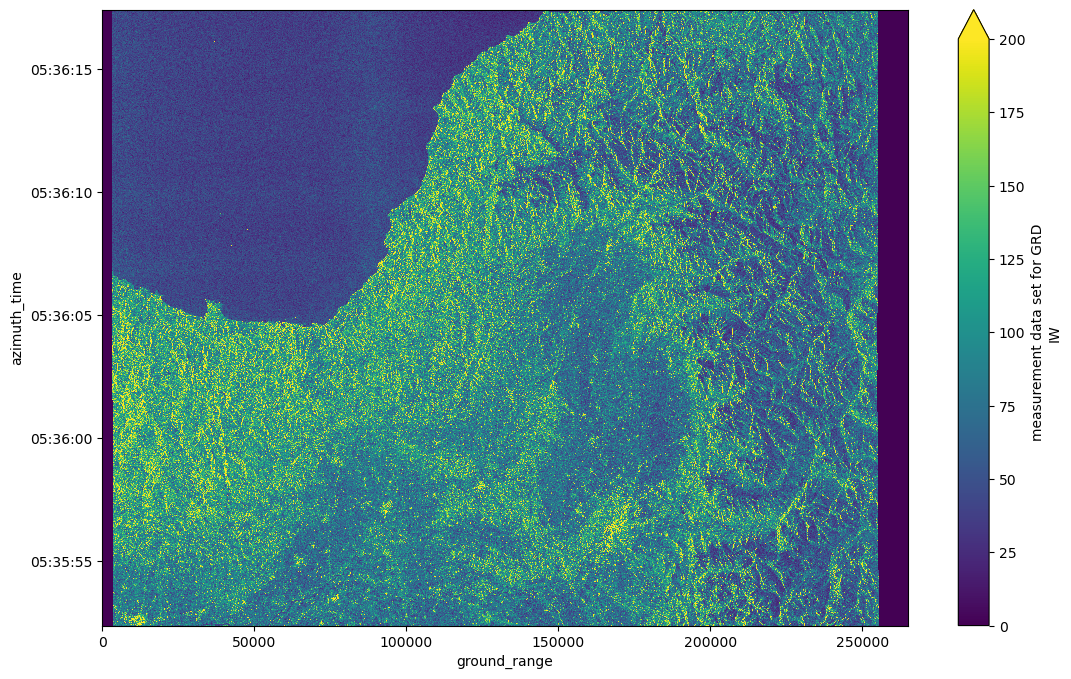

In [6]:
ds.grd[::10, ::10].plot(vmax=200, figsize=(13, 8))

### Open Sentinel-1 GRD VH group in native mode as Dataset

Similarily, we can open the individual polarisation bands (assets `"vh"` and `"vv"`) to open the individual groups as an `xarray.Dataset` as shown below:

In [7]:
%%time
ds = xr.open_dataset(
    item.assets["vh"].href,
    **item.assets["vh"].extra_fields["xarray:open_dataset_kwargs"],
)
ds

CPU times: user 99.2 ms, sys: 23.5 ms, total: 123 ms
Wall time: 1.28 s


<xarray.Dataset> Size: 884MB
Dimensions:       (azimuth_time: 16669, ground_range: 26492)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 133kB 2026-03-29T05:35:52.402...
    line          (azimuth_time) int64 133kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 212kB 0.0 10.0 ... 2.649e+05 2.649e+05
    pixel         (ground_range) int64 212kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    grd           (azimuth_time, ground_range) uint16 883MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

### Open Sentinel-1 GRD as Dataset

The `xarray.DataTree` model was introduced in xarray v2024.10.0 (October 2024). To maintain compatibility with workflows based on `xr.Dataset`, the function `xarray.open_dataset(..., engine="eopf-zarr", op_mode="native")` is provided, which flattens the `DataTree` into a single dataset.

During this process, hierarchical groups in the Zarr product are merged, and variable as well as dimension names are prefixed with their group paths (using `_` by default) to ensure uniqueness. For example, `S01SIWGRD_20260316T045550_0025_A364_7C56_080022_VH.measurements` becomes `S01SIWGRD_20260316T045550_0025_A364_7C56_080022_VH_measurements`.

In [8]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
)
ds

CPU times: user 775 ms, sys: 55.9 ms, total: 831 ms
Wall time: 3.34 s


<xarray.Dataset> Size: 2GB
Dimensions:                                                           (
                                                                       VH_conditions_antenna_pattern_azimuth_time: 27,
                                                                       VH_conditions_antenna_pattern_count: 721,
                                                                       VH_conditions_attitude_azimuth_time: 25,
                                                                       VH_conditions_doppler_centroid_azimuth_time: 27,
                                                                       VH_conditions_doppler_centroid_degree: 3,
                                                                       ...
                                                                       VV_quality_calibration_azimuth_time: 27,
                                                                       VV_quality_calibration_ground_range: 664,
                                                                       VV_quality_azimuth_swath: 3,
                                                                       VV_quality_azimuth_azimuth_time: 1687,
                                                                       VV_quality_range_azimuth_time: 26,
                                                                       VV_quality_range_ground_range: 666)
Coordinates: (12/58)
  * VH_conditions_antenna_pattern_azimuth_time                        (VH_conditions_antenna_pattern_azimuth_time) datetime64[ns] 216B ...
  * VH_conditions_antenna_pattern_count                               (VH_conditions_antenna_pattern_count) int64 6kB ...
  * VH_conditions_attitude_azimuth_time                               (VH_conditions_attitude_azimuth_time) datetime64[ns] 200B ...
  * VH_conditions_doppler_centroid_azimuth_time                       (VH_conditions_doppler_centroid_azimuth_time) datetime64[ns] 216B ...
  * VH_conditions_doppler_centroid_degree                             (VH_conditions_doppler_centroid_degree) int64 24B ...
  * VH_conditions_gcp_azimuth_time                                    (VH_conditions_gcp_azimuth_time) datetime64[ns] 80B ...
    ...                                                                ...
    VV_quality_azimuth_last_range_sample                              (VV_quality_azimuth_swath) int32 12B dask.array<chunksize=(3,), meta=np.ndarray>
    VV_quality_azimuth_line                                           (VV_quality_azimuth_swath, VV_quality_azimuth_azimuth_time) int32 20kB dask.array<chunksize=(3, 1687), meta=np.ndarray>
  * VV_quality_range_azimuth_time                                     (VV_quality_range_azimuth_time) datetime64[ns] 208B ...
    VV_quality_range_line                                             (VV_quality_range_azimuth_time) int32 104B dask.array<chunksize=(26,), meta=np.ndarray>
  * VV_quality_range_ground_range                                     (VV_quality_range_ground_range) float64 5kB ...
    VV_quality_range_pixel                                            (VV_quality_range_ground_range) int32 3kB dask.array<chunksize=(666,), meta=np.ndarray>
Dimensions without coordinates: VH_quality_azimuth_azimuth_time,
                                VV_quality_azimuth_azimuth_time
Data variables: (12/78)
    VH_conditions_antenna_pattern_elevation_angle                     (VH_conditions_antenna_pattern_azimuth_time, VH_conditions_antenna_pattern_count) float32 78kB dask.array<chunksize=(27, 721), meta=np.ndarray>
    VH_conditions_antenna_pattern_incidence_angle                     (VH_conditions_antenna_pattern_azimuth_time, VH_conditions_antenna_pattern_count) float32 78kB dask.array<chunksize=(27, 721), meta=np.ndarray>
    VH_conditions_antenna_pattern_roll                                (VH_conditions_antenna_pattern_azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
    VH_conditions_antenna_pattern_slant_range_time_ap              

The separator character used in flattened variable names can be customized via the `group_sep` parameter. Additionally, you can filter the returned variables using the `variables` keyword argument, which accepts a string, an iterable of names, or a regular expression (regex) pattern.

In this example, we use a regex to select all arrays associated with the VH band.

In [9]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
    group_sep="/",
    variables="^VH.*",
)
ds

<xarray.Dataset> Size: 884MB
Dimensions:                                                           (
                                                                       VH/conditions/antenna_pattern/azimuth_time: 27,
                                                                       VH/conditions/antenna_pattern/count: 721,
                                                                       VH/conditions/attitude/azimuth_time: 25,
                                                                       VH/conditions/doppler_centroid/azimuth_time: 27,
                                                                       VH/conditions/doppler_centroid/degree: 3,
                                                                       ...
                                                                       VH/quality/calibration/azimuth_time: 27,
                                                                       VH/quality/calibration/ground_range: 664,
                                                                       VH/quality/azimuth/swath: 3,
                                                                       VH/quality/azimuth/azimuth_time: 1687,
                                                                       VH/quality/range/azimuth_time: 26,
                                                                       VH/quality/range/ground_range: 666)
Coordinates: (12/16)
  * VH/conditions/antenna_pattern/azimuth_time                        (VH/conditions/antenna_pattern/azimuth_time) datetime64[ns] 216B ...
  * VH/conditions/antenna_pattern/count                               (VH/conditions/antenna_pattern/count) int64 6kB ...
  * VH/conditions/attitude/azimuth_time                               (VH/conditions/attitude/azimuth_time) datetime64[ns] 200B ...
  * VH/conditions/doppler_centroid/azimuth_time                       (VH/conditions/doppler_centroid/azimuth_time) datetime64[ns] 216B ...
  * VH/conditions/doppler_centroid/degree                             (VH/conditions/doppler_centroid/degree) int64 24B ...
  * VH/conditions/gcp/azimuth_time                                    (VH/conditions/gcp/azimuth_time) datetime64[ns] 80B ...
    ...                                                                ...
  * VH/measurements/ground_range                                      (VH/measurements/ground_range) float64 212kB ...
  * VH/quality/calibration/azimuth_time                               (VH/quality/calibration/azimuth_time) datetime64[ns] 216B ...
  * VH/quality/calibration/ground_range                               (VH/quality/calibration/ground_range) float64 5kB ...
  * VH/quality/azimuth/swath                                          (VH/quality/azimuth/swath) <U3 36B ...
  * VH/quality/range/azimuth_time                                     (VH/quality/range/azimuth_time) datetime64[ns] 208B ...
  * VH/quality/range/ground_range                                     (VH/quality/range/ground_range) float64 5kB ...
Dimensions without coordinates: VH/quality/azimuth/azimuth_time
Data variables: (12/39)
    VH/conditions/antenna_pattern/elevation_angle                     (VH/conditions/antenna_pattern/azimuth_time, VH/conditions/antenna_pattern/count) float32 78kB dask.array<chunksize=(27, 721), meta=np.ndarray>
    VH/conditions/antenna_pattern/incidence_angle                     (VH/conditions/antenna_pattern/azimuth_time, VH/conditions/antenna_pattern/count) float32 78kB dask.array<chunksize=(27, 721), meta=np.ndarray>
    VH/conditions/antenna_pattern/roll                                (VH/conditions/antenna_pattern/azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
    VH/conditions/antenna_pattern/slant_range_time_ap                 (VH/conditions/antenna_pattern/azimuth_time, VH/conditions/antenna_pattern/count) float64 156kB dask.array<chunksize=(27, 721), meta=np.ndarray>
    VH/conditions/antenna_pattern/swath                               (VH/conditions/ant

We can now plot the GRD array and the coarse 2d latitude and longitude grids, which can be used for geolocation.

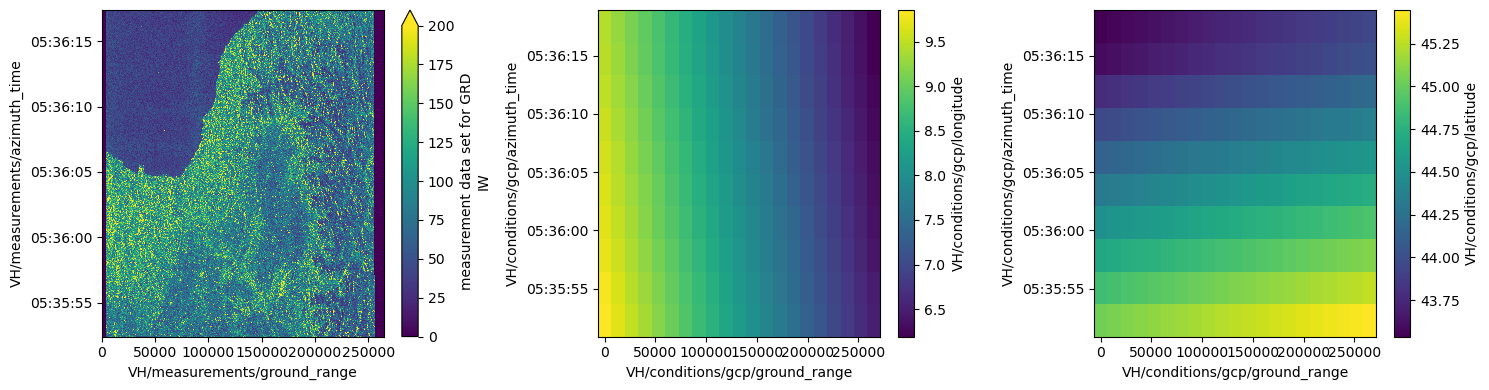

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ds["VH/measurements/grd"][::10, ::10].plot.imshow(ax=ax[0], vmax=200)
ds["VH/conditions/gcp/longitude"].plot.imshow(ax=ax[1])
ds["VH/conditions/gcp/latitude"].plot.imshow(ax=ax[2])
plt.tight_layout()

---

(Open_OCN_XEOPF_SEN1_NATIVE)=
## Open a Sentinel-1 Level-2 OCN

We now access a Sentinel-1 Level-2 OCN product in **native mode**. The data access methods shown above apply equally to Sentinel-1 Level-2 OCN products.

### Find a Sentinel-1 Level-2 OCN Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l2-ocn) to search for available Sentinel-1 Level-2 OCN tiles.

In [11]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l2-ocn"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=365)), None],
    ).items()
)
items

[<Item id=S1C_IW_OCN__2SDV_20250727T172200_20250727T172225_003409_006DAD_7517>,
 <Item id=S1C_IW_OCN__2SDV_20250726T053506_20250726T053531_003387_006D07_5CDB>,
 <Item id=S1A_IW_OCN__2SDV_20250725T054423_20250725T054448_060236_077C52_B0C4>,
 <Item id=S1C_IW_OCN__2SDV_20250608T053504_20250608T053529_002687_0058C3_0307>,
 <Item id=S1C_IW_OCN__2SDV_20250528T172156_20250528T172221_002534_00545C_B05B>,
 <Item id=S1C_IW_OCN__2SDV_20250527T053503_20250527T053528_002512_0053BB_6400>,
 <Item id=S1A_IW_OCN__2SDV_20250526T054426_20250526T054451_059361_075E24_149E>,
 <Item id=S1C_IW_OCN__2SDV_20250521T173000_20250521T173025_002432_00517D_7E24>,
 <Item id=S1A_IW_OCN__2SDV_20250521T053603_20250521T053628_059288_075B98_AA29>,
 <Item id=S1C_IW_OCN__2SDV_20250516T172154_20250516T172219_002359_004F85_9A03>,
 <Item id=S1C_IW_OCN__2SDV_20250515T053501_20250515T053526_002337_004EE6_9031>,
 <Item id=S1A_IW_OCN__2SDV_20250514T054426_20250514T054451_059186_075813_CC48>,
 <Item id=S1C_IW_OCN__2SDV_20250509T1729

In [12]:
item = items[0]
item

<Item id=S1C_IW_OCN__2SDV_20250727T172200_20250727T172225_003409_006DAD_7517>

### Open Sentinel-1 Level-2 OCN as DataTree

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [13]:
%%time
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)
dt

CPU times: user 246 ms, sys: 8.68 ms, total: 255 ms
Wall time: 654 ms


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /osw
│   │   Attributes: (2)
│   └── Group: /osw/S01SIWOCN_20250727T172200_0025_C020_7517_006DAD_VV
│       │   Attributes: (2)
│       ├── Group: /osw/S01SIWOCN_20250727T172200_0025_C020_7517_006DAD_VV/conditions
│       │       Dimensions:                                 (azimuth: 1, range: 1,
│       │                                                    partition: 1, lag: 1, ky: 1,
│       │                                                    kx: 1, angular_binsize: 1,
│       │                                                    wavenumber_binsize: 1)
│       │       Coordinates:
│       │           latitude                                (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           longitude                               (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │         * ky                                      (ky) float32 4B nan
│       │           jy                                      (ky) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │         * kx                                      (kx) float32 4B nan
│       │           jx                                      (kx) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │           phi                                     (angular_binsize) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │           k                                       (wavenumber_binsize) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │       Dimensions without coordinates: azimuth, range, partition, lag,
│       │                                       angular_binsize, wavenumber_binsize
│       │       Data variables: (12/31)
│       │           ambiguity_factor                        (azimuth, range, partition) float32 4B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
│       │           auxiliary_wind_direction                (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           auxiliary_wind_speed                    (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           azimuth_cutoff                          (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           azimuth_size                            (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           azimuth_size_slc                        (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           ...                                      ...
│       │           range_cutoff                            (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           range_size_slc                          (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           skewness                                (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           spectrum_resolution                     (azimuth, range, angular_binsize) float32 4B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
│       │           wind_direction                          (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           wind_speed                              (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       ├── Group: /osw/S01SIWOCN_20250727T172200_0025_C020_7517_006DAD_VV/measurements
│       │       Dimensions:                      (azimuth: 1, range: 1, partition: 1,
│       │                                         angular_binsize: 1, wavenumber_binsize: 1)
│       │       Coordinates:
│       │           latitude                     (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           longitude                    (azimuth, range) float32 4B dask.array

We can extract the ocean wind field dataset as shown below:

In [14]:
ds = dt[dt.owi.groups[1]].measurements.to_dataset()
ds

<xarray.Dataset> Size: 704kB
Dimensions:         (azimuth: 166, range: 265)
Coordinates:
    latitude        (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    longitude       (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
Dimensions without coordinates: azimuth, range
Data variables:
    wind_direction  (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    wind_speed      (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>

As an example, we plot the two ocean wind field array. 

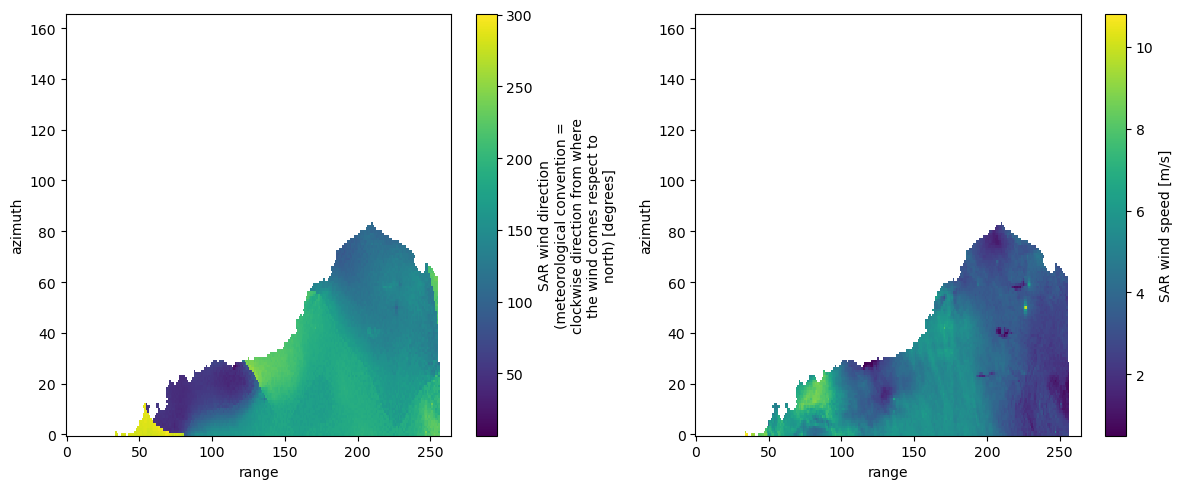

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.wind_direction.plot(ax=ax[0])
ds.wind_speed.plot(ax=ax[1])
plt.tight_layout()

### Open Sentinel-1 Level-2 OCN OWI Group as Dataset

We can access the individual sub-groups directly by using the assets `"osw"`, `"owi"`, and `"rvl"`. The opening parameters are stored in the asset’s extra field `"xarray:open_dataset_kwargs"`.

In [16]:
ds = xr.open_dataset(
    item.assets["owi"].href,
    **item.assets["owi"].extra_fields["xarray:open_dataset_kwargs"],
)
ds

<xarray.Dataset> Size: 704kB
Dimensions:         (azimuth: 166, range: 265)
Coordinates:
    latitude        (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    longitude       (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
Dimensions without coordinates: azimuth, range
Data variables:
    wind_direction  (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    wind_speed      (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>

---

(Conclusion_XEOPF_SEN1_NATIVE)=
## Conclusion

This notebook demonstrates how to access Sentinel-1 EOPF Zarr samples in **native mode** using the **xarray-eopf** plugin. Key takeaways are:

- Access Sentinel-1 Level-1 GRD, and Sentinel-1 Level-2 OCN products.  
- Open the full Zarr store as an `xr.DataTree` using `xr.open_datatree` and the asset `"product"`.  
- Open subgroups (e.g., `"vh"`, `"vv"`, `"owi"`, and `"rvl"`) as `xr.Dataset` using `xr.open_dataset`.  
- Open the full Zarr store as a flattened `xr.Dataset` using `xr.open_dataset` and the asset `"product"`.  
- Filter variables using the `variables` keyword argument.

> **Note:**  
> This notebook only covers the **native mode**, which presents the data as close as possible to the original product.  
> The **anaylsis mode** will be presented once implemented.  
> Examples for Sentienl-1 SLC will be presented once updated Zarr samples are published through the STAC API.  

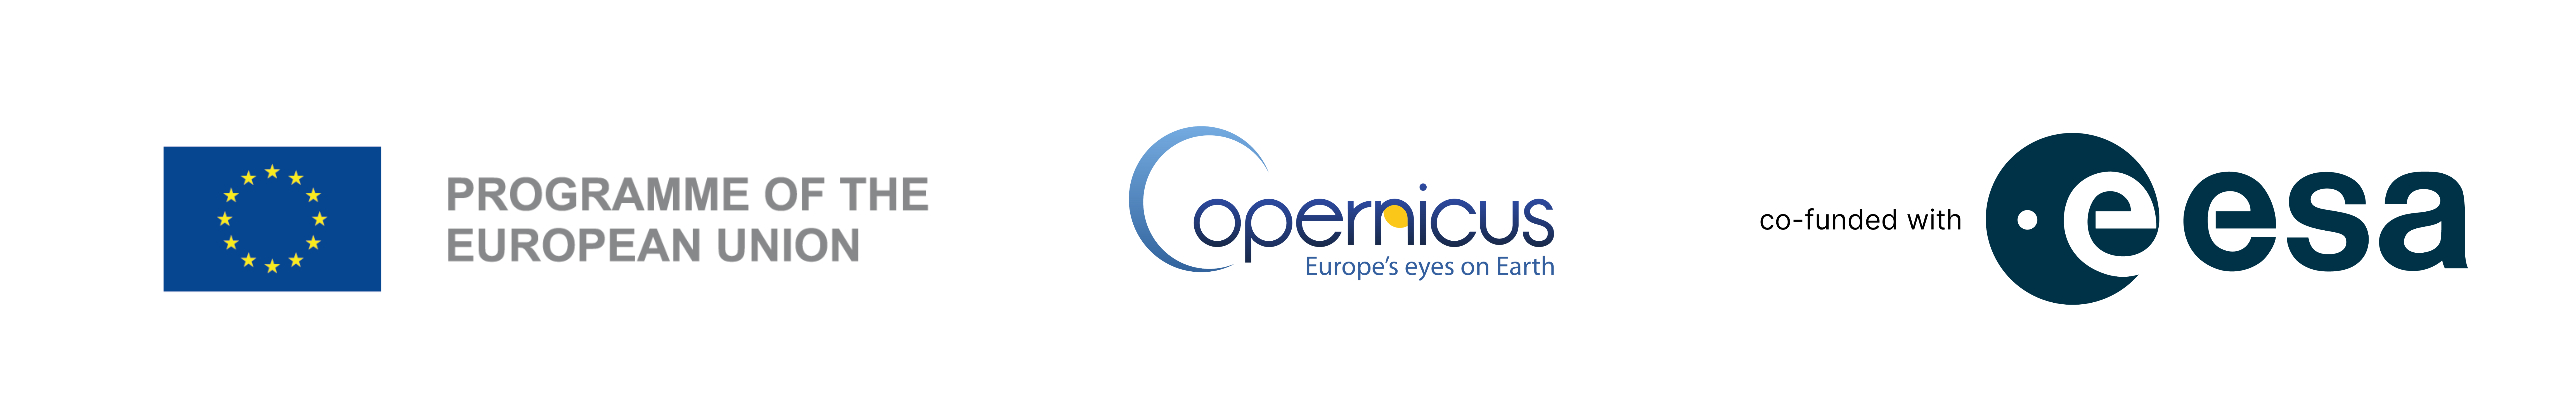